In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Window length
N = 256

# Hann window
n = np.arange(N)
hann = 0.5 - 0.5 * np.cos(2 * np.pi * n / (N - 1))

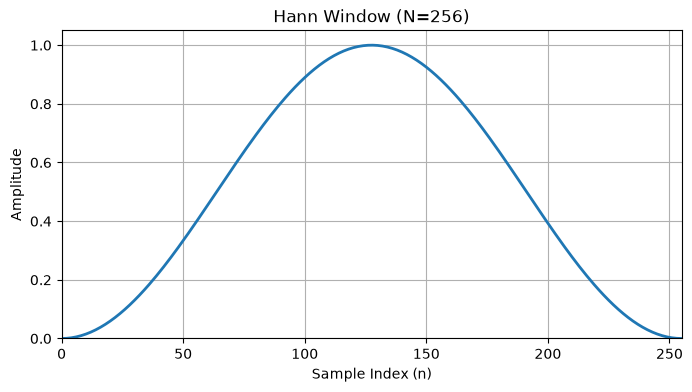

In [4]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(n, hann, linewidth=2)
plt.title(f"Hann Window (N={N})")
plt.xlabel("Sample Index (n)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim(0, N - 1)
plt.ylim(0, 1.05)
plt.show()

In [5]:

a = 8  # Lanczos-8 (17 taps)
# Continuous x-axis
x = np.linspace(-a, a, a*400)


In [6]:
# Adjustable scaling factor
c = 1.0

# np.sinc(x) = sin(pi*x)/(pi*x)
L = np.sinc(c*x) * np.sinc(c*x / a)
L[np.abs(x) >= a] = 0

# Integer tap locations
n = np.arange(-a, a+1)
Ln = np.sinc(n) * np.sinc(n / a)
Ln[np.abs(n) >= a] = 0

In [7]:


# Continuous Hann window over [-8, 8]
hann = np.zeros_like(x)
mask = np.abs(x) <= a
hann[mask] = 0.5 * (1 + np.cos(np.pi * x[mask] / a))

# Windowed sinc
L_hann = c * np.sinc(c * x) * hann

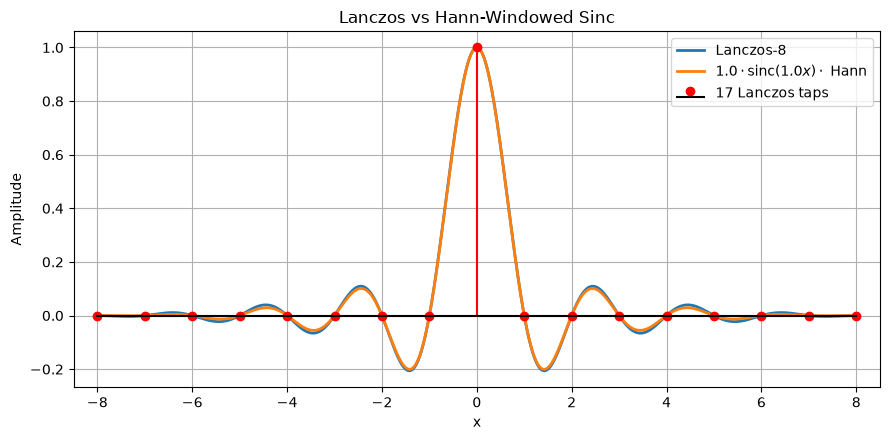

In [8]:
plt.figure(figsize=(9, 4.5))

plt.plot(x, L, linewidth=2, label="Lanczos-8")
plt.plot(x, L_hann, linewidth=2, label=rf"${c} \cdot \mathrm{{sinc}}({c}x)\cdot$ Hann")


plt.stem(n, Ln, linefmt='r-', markerfmt='ro', basefmt='k-',
         label="17 Lanczos taps")

plt.title("Lanczos vs Hann-Windowed Sinc")
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.xlim(-a-0.5, a+0.5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
""" Chatgpt generated frquency domain response"""
# ----- Discrete FIR frequency response -----

# Discrete Hann-windowed sinc taps
hann_n = 0.5 * (1 + np.cos(np.pi * n / a))
L_hann_n = c * np.sinc(c * n) * hann_n

Nfft = 32768

# FFT of the discrete kernels
H_lanczos = np.fft.fftshift(np.fft.fft(Ln, Nfft))
H_hann    = np.fft.fftshift(np.fft.fft(L_hann_n, Nfft))

# Frequency axis: -1 to 1 (× Nyquist)
f = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1.0)) / 0.5

# Normalize DC gain
H_lanczos = np.abs(H_lanczos)
H_hann = np.abs(H_hann)
H_lanczos /= H_lanczos.max()
H_hann /= H_hann.max()

# Ideal brick-wall response
ideal = (np.abs(f) <= c).astype(float)

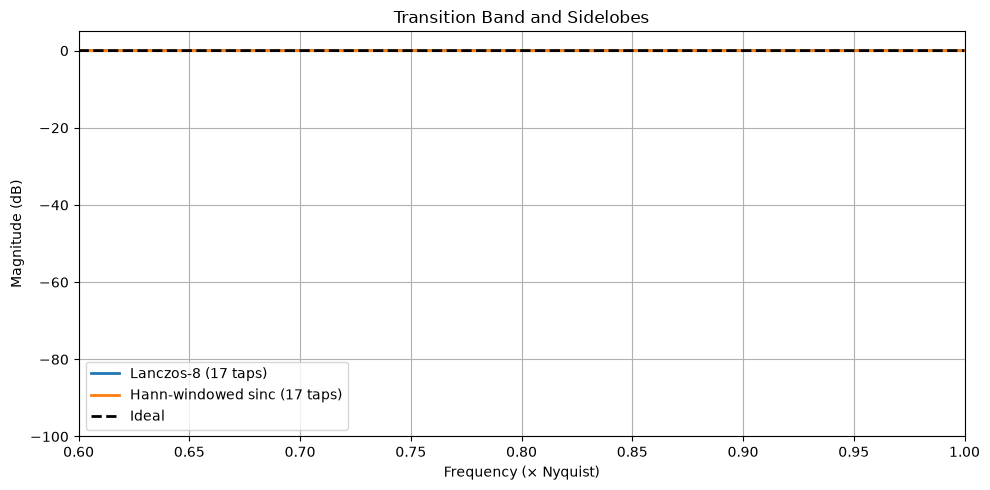

In [10]:
# Convert to dB
eps = 1e-15
H_lanczos_db = 20*np.log10(H_lanczos + eps)
H_hann_db = 20*np.log10(H_hann + eps)

plt.figure(figsize=(10,5))

plt.plot(f, H_lanczos_db, linewidth=2, label="Lanczos-8 (17 taps)")
plt.plot(f, H_hann_db, linewidth=2, label="Hann-windowed sinc (17 taps)")
plt.plot(f, 20*np.log10(ideal + eps), "k--", linewidth=2, label="Ideal")

# Zoom near Nyquist to reveal sidelobes
plt.xlim(0.6, 1)
plt.ylim(-100, 5)

plt.xlabel("Frequency (× Nyquist)")
plt.ylabel("Magnitude (dB)")
plt.title("Transition Band and Sidelobes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

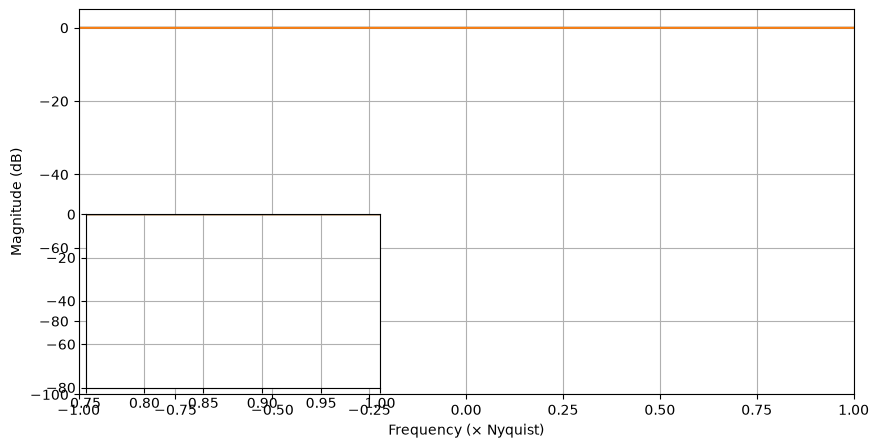

In [11]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(f, H_lanczos_db, label="Lanczos-8")
ax.plot(f, H_hann_db, label="Hann-windowed sinc")

ax.set_xlim(-1,1)
ax.set_ylim(-100,5)
ax.set_xlabel("Frequency (× Nyquist)")
ax.set_ylabel("Magnitude (dB)")
ax.grid(True)
ax.legend()

# Inset showing sidelobes near Nyquist
axins = inset_axes(ax, width="38%", height="45%", loc="lower left")
axins.plot(f, H_lanczos_db)
axins.plot(f, H_hann_db)
axins.set_xlim(0.75,1.0)
axins.set_ylim(-80,0)
axins.grid(True)

#plt.tight_layout()
plt.show()